# GS STARR Track 1 SEMDB — Steps 00–05

Pipeline corretta fino allo Step 05.

- Step 00: runner opzionale.
- Step 01: raster extraction + griglia UTM corretta.
- Step 02: low-RAM matching + hard calipers + SMD.
- Step 03: twin test / parallel trends.
- Step 04: locked Reference Area.
- Step 05: 90% Confidence Interval + `UNCBSL`.

Lo Step 05 calcola solo il confidence interval baseline e `UNCBSL`. Non calcola activity removals, `UNCAR`, leakage, net removals o GSVER finali.


---
## 0. Setup ambiente


In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.figsize'] = (13, 5)

# Colab: decommentare se i file sono su Google Drive.
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio pyproj geopandas shapely scikit-learn scipy pyarrow -q
print('Environment OK')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment OK


---
## 1. Parametri principali

Modifica solo questa cella prima del run.


In [2]:
from pathlib import Path
import json, importlib.util, warnings
warnings.filterwarnings('ignore')

# Directory dove sono copiati gli script 00–05.
SCRIPTS_DIR = Path('/content/drive/MyDrive/Starr_Scripts_V3')

# Directory dove cercare i GeoTIFF esportati da GEE.
RASTER_DIR = Path('/content/drive/MyDrive/STARR_Idiofa_New_V2')

# RUN_ID usato nei prefissi dei raster:
# covariates_project_<RUN_ID>*.tif
# covariates_donor_<RUN_ID>*.tif
RUN_ID = 'Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster'
PROJECT_NAME = 'Idiofa_Lobi'

# Root output. Se None, Step 01 scrive in RASTER_DIR/STARR_outputs/RUN_ID/01_extract.
OUTPUT_ROOT = RASTER_DIR / 'STARR_outputs' / RUN_ID

# Step 05 richiede dati carbon-stock-change per i pixel controllo locked.
# Può essere saltato fino a quando il file non esiste.
RUN_STEP_05 = True

# File atteso per Step 05, in una delle cartelle 02/03/04/05 o passato come dataframe:
# control_carbon_stock_change.parquet/csv
# colonne accettate:
#   deltaC_control_tC_ha_yr
# oppure:
#   C_ref_t0_tC_ha + C_ref_y_tC_ha
# oppure:
#   AGB_ref_t0_Mg_ha + AGB_ref_y_Mg_ha

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('SCRIPTS_DIR:', SCRIPTS_DIR)
print('RASTER_DIR :', RASTER_DIR)
print('OUTPUT_ROOT:', OUTPUT_ROOT)


SCRIPTS_DIR: /content/drive/MyDrive/Starr_Scripts_V3
RASTER_DIR : /content/drive/MyDrive/STARR_Idiofa_New_V2
OUTPUT_ROOT: /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster


---
## 2. Caricamento moduli 00–05


In [3]:
def load_module(module_name, filename):
    path = SCRIPTS_DIR / filename
    if not path.exists():
        raise FileNotFoundError(path)
    spec = importlib.util.spec_from_file_location(module_name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

s01 = load_module('s01', '01_STARR_raster_extract.py')
s02 = load_module('s02', '02_STARR_matching_data_weights.py')
s03 = load_module('s03', '03_STARR_twin_test_selection.py')
s04 = load_module('s04', '04_STARR_reference_area_lock.py')
s05 = load_module('s05', '05_STARR_baseline_confidence_interval_UNCBSL.py')

# Applica configurazione runtime.
s01.RUN_ID = RUN_ID
s01.PROJECT_NAME = PROJECT_NAME
s01.BASE_DIR_CANDIDATES = [str(RASTER_DIR)]
s01.PROJECT_TIF_PATTERN = f'covariates_project_{RUN_ID}*.tif'
s01.DONOR_TIF_PATTERN = f'covariates_donor_{RUN_ID}*.tif'
s01.BLOCK_HEIGHT = 2048

s05.RUN_ID = RUN_ID
s05.PROJECT_NAME = PROJECT_NAME
s05.BASE_DIR_CANDIDATES = [str(OUTPUT_ROOT)]

# Step 02 low-RAM defaults.
s02.K_NEIGHBOURS = 20
s02.KNN_QUERY_CANDIDATES = 150
s02.N_DONOR_SAMPLE = 500_000
s02.KNN_N_JOBS = 1 if hasattr(s02, 'KNN_N_JOBS') else 1

print('Loaded modules: s01 | s02 | s03 | s04 | s05')


Loaded modules: s01 | s02 | s03 | s04 | s05


---
## 3. STEP 01 — Raster extraction



STEP 01 — Raster Extraction | Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster
Output: /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster/01_extract

[1] Ricerca tiles...
    Project: 1 tile trovate
      covariates_project_Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster.tif
    Donor: 1 tile trovate
      covariates_donor_Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster.tif

[2] Estrazione PROJECT...
    CRS: EPSG:32734 | pixel: 30.0 m
    covariates_project_Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster.tif
      1181×1555px | EPSG:32734 | 17 bande
      Origin: (314160.00, 9465630.00) | Pixel: 30.0×30.0 m
      → 107,405 px (2.3s)
    Project: 107,405 px | T0=2018 | NDVI=[2013, 2014, 2015, 2016, 2017]

[3] Estrazione DONOR...
    CRS: EPSG:32734 | pixel: 30.0 m
    covariates_donor_Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster.tif
      5854×6198px | EPSG:32734 | 17 bande
      Origin: (244050.00, 9535260.00) | Pixel: 30.

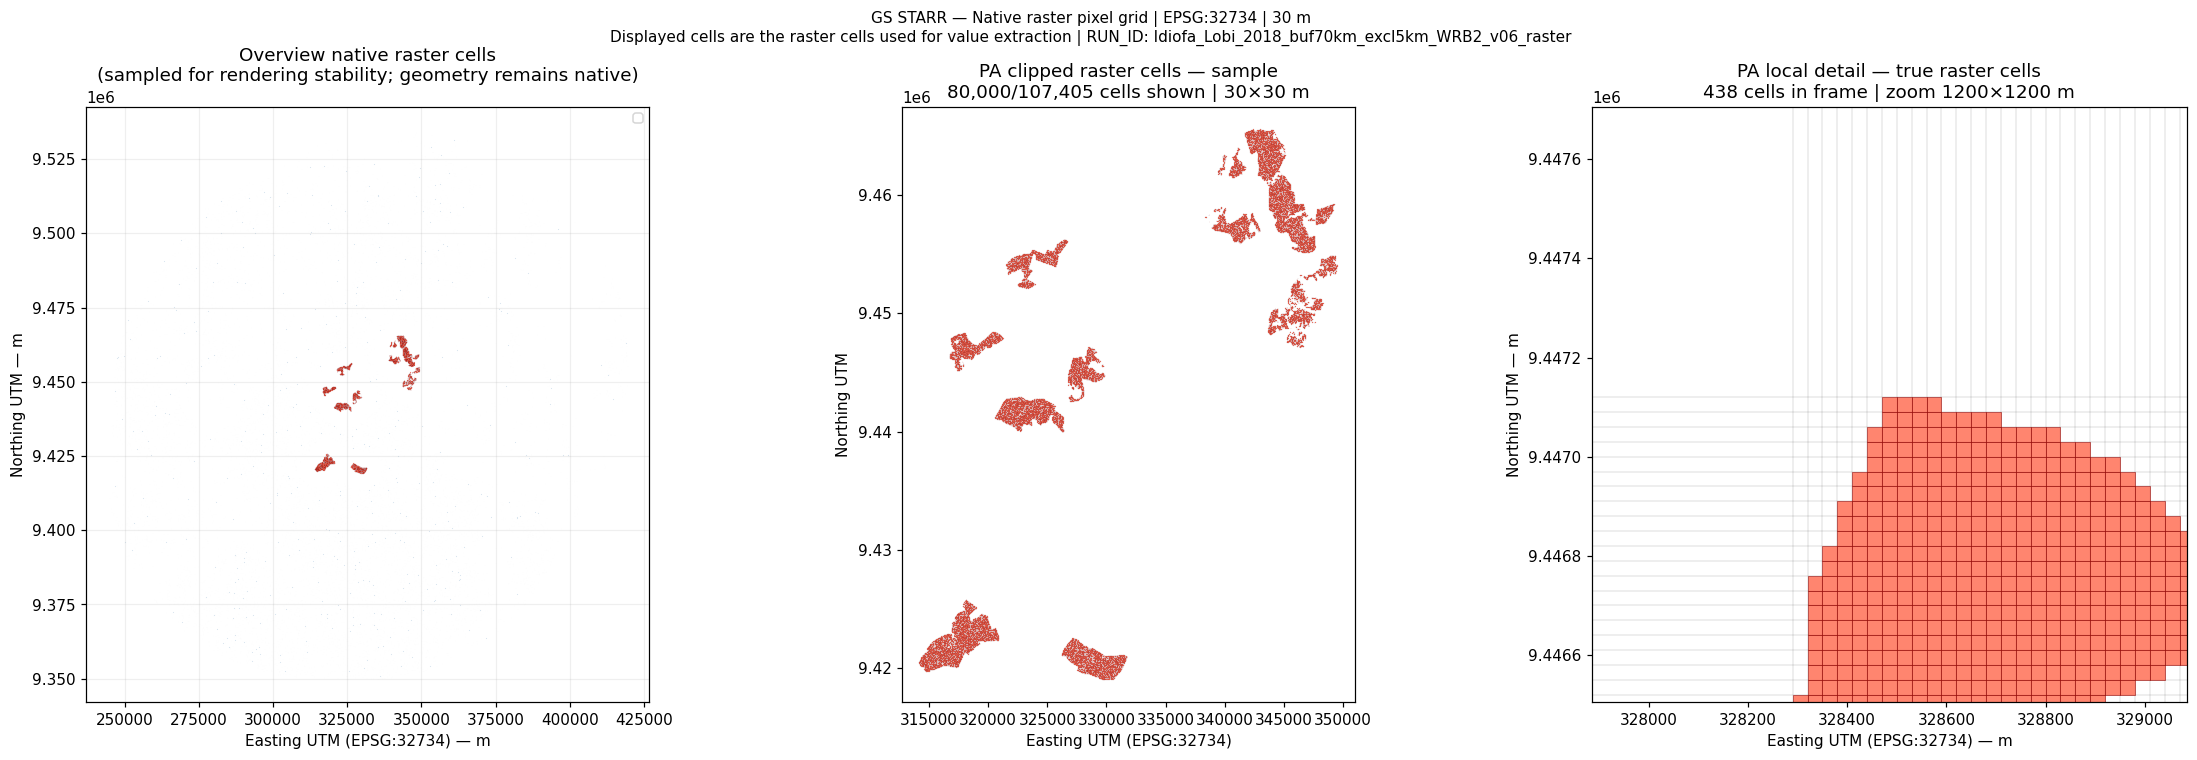

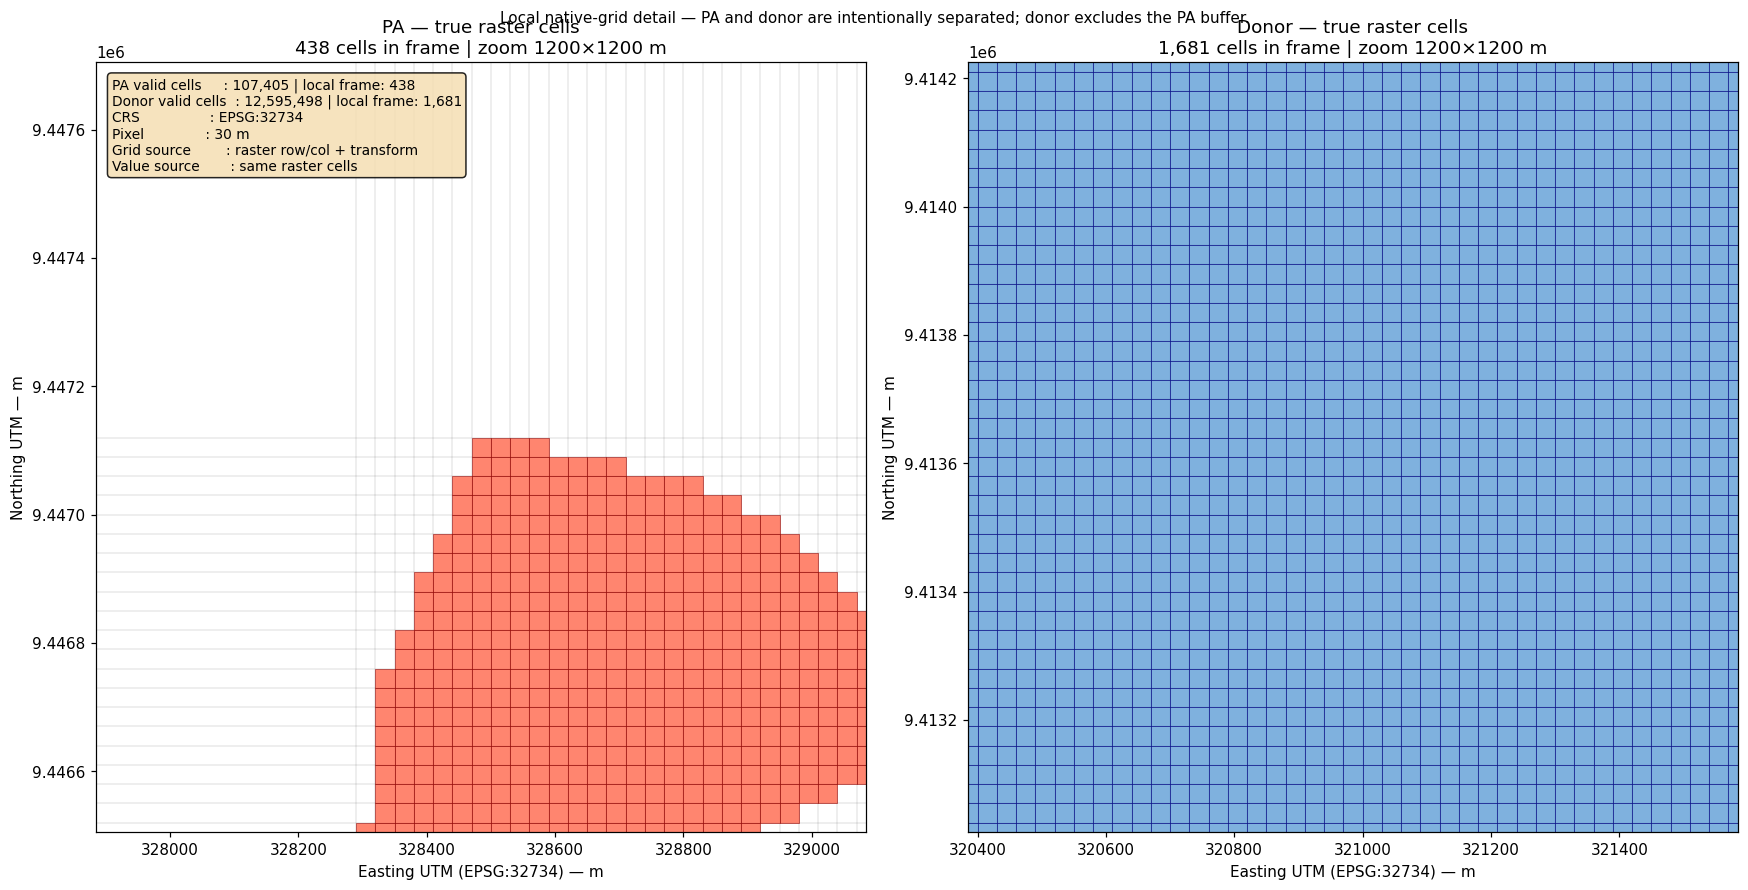

In [4]:
STEP01_OUT = OUTPUT_ROOT / '01_extract'
proj_df, donor_df, meta, out01 = s01.run_extraction(
    base_dirs=[RASTER_DIR],
    output_dir=STEP01_OUT,
    verbose=True,
)
print('Step 01 output:', out01)
print('Project pixels:', len(proj_df))
print('Donor pixels  :', len(donor_df))
print('T0 year       :', meta.get('t0_year'))
print('NDVI years    :', meta.get('year_list'))
print('Covariates    :', meta.get('continuous_covariates'))


---
## 4. STEP 02 — Matching low-RAM + SMD


In [ ]:
STEP02_OUT = OUTPUT_ROOT / '02_matching'
matched_df, weights_dict, imp_df, smd_df, figs02, out02 = s02.run_matching_step(
    base_dirs=[out01],
    output_dir=STEP02_OUT,
    proj_df=proj_df,
    donor_df=donor_df,
    meta=meta,
    verbose=True,
)
print('Step 02 output:', out02)
print('Matched rows:', len(matched_df))
display(smd_df)



STEP 02 | Plain Mahalanobis | K=20 | candidates=150
NO DOWNCAST | donor streamed=False | donor cap=500,000
Output: /content/drive/MyDrive/STARR_Idiofa_New_V2/STARR_outputs/Idiofa_Lobi_2018_buf70km_excl5km_WRB2_v06_raster/02_matching

[1] Project texture + numeric validation (no downcast)
    Project WRB filter: 107,405 → 107,405
    Project dropna: 107,405 → 107,405
    Project: 107,405

[2] Donor in-memory texture + numeric validation + loose prefilter


---
## 5. STEP 03 — Twin test / Parallel trends


In [ ]:
STEP03_OUT = OUTPUT_ROOT / '03_twin_test'
all_pairs, twin_pixels, twin_report, figs03, out03 = s03.run_twin_test(
    base_dirs=[out02],
    output_dir=STEP03_OUT,
    matched_df=matched_df,
    proj_df=proj_df,
    meta=meta,
    verbose=True,
)
print('Step 03 output:', out03)
print('Twin-tested pixels:', len(twin_pixels))
print(json.dumps(twin_report, indent=2)[:4000])


---
## 6. STEP 04 — Locked Reference Area


In [ ]:
STEP04_OUT = OUTPUT_ROOT / '04_reference_area'
bounds_gdf, mon_gdf, fig04, out04, manifest = s04.run_reference_area_lock(
    base_dirs=[out03],
    output_dir=STEP04_OUT,
    passed_df=twin_pixels,
    meta=meta,
    twin_report=twin_report,
    verbose=True,
)
print('Step 04 output:', out04)
print('RA rows:', len(bounds_gdf))
print('Monitoring points:', len(mon_gdf))
print(json.dumps(manifest, indent=2)[:4000])


---
## 7. STEP 05 — Baseline 90% Confidence Interval / UNCBSL

Eseguire solo quando sono disponibili i dati di carbon-stock-change dei pixel controllo locked.

File accettato: `control_carbon_stock_change.parquet` oppure `.csv`.


In [ ]:
if RUN_STEP_05:
    STEP05_OUT = OUTPUT_ROOT / '05_baseline_CI_UNCBSL'
    control_pixels, ci_summary, ci_report, fig05, out05 = s05.run_baseline_ci_uncbsl(
        base_dirs=[OUTPUT_ROOT],
        output_dir=STEP05_OUT,
        twin_df=twin_pixels,
        control_change_df=None,
        manifest=manifest,
        verbose=True,
    )
    print('Step 05 output:', out05)
    display(control_pixels.head())
    display(__import__('pandas').DataFrame([ci_summary]))
else:
    print('Step 05 skipped. It requires control carbon-stock-change data.')


---
## 8. Output checklist


In [ ]:
for p in [OUTPUT_ROOT / '01_extract', OUTPUT_ROOT / '02_matching', OUTPUT_ROOT / '03_twin_test', OUTPUT_ROOT / '04_reference_area', OUTPUT_ROOT / '05_baseline_CI_UNCBSL']:
    print('
' + str(p))
    if p.exists():
        for f in sorted(p.iterdir()):
            print('  -', f.name)
    else:
        print('  missing')
